In [1]:
import pandas as pd 

train_df = pd.read_csv("titanic/train.csv")
train_df["train"]=True
test_df = pd.read_csv("titanic/test.csv")
test_df["train"]=False

In [2]:
train_df.shape

(891, 13)

In [3]:
train_df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked', 'train'],
      dtype='str')

In [4]:
train_df['Title'] = train_df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
train_df['Title'].value_counts()

Title
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Major         2
Mlle          2
Col           2
Don           1
Mme           1
Ms            1
Lady          1
Sir           1
Capt          1
Countess      1
Jonkheer      1
Name: count, dtype: int64

In [5]:
train_df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
train            0
Title            0
dtype: int64

Deal with Age first

In [43]:
from sklearn.impute import SimpleImputer

age_imputer = SimpleImputer(strategy="mean")
train_df["Age"] = age_imputer.fit_transform(train_df[["Age"]])
train_df["Embarked"] = train_df["Embarked"].fillna(train_df["Embarked"].mode()[0])
train_df["Cabin_Deck"] = train_df["Cabin"].str[0]

In [44]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     891 non-null    str    
 12  train        891 non-null    bool   
 13  Title        891 non-null    str    
 14  Cabin_Deck   204 non-null    str    
dtypes: bool(1), float64(2), int64(5), str(7)
memory usage: 136.3 KB


In [50]:
str_cols = ["Sex","Ticket","Cabin","Embarked","Title","Cabin_Deck"]
num_cols = ["Age","Fare"]
rest_cols = ["Pclass","Age","SibSp","Parch"]

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split

cabin_X_train = train_df[train_df["Cabin"].notna()]
cabin_X_test = train_df[train_df["Cabin"].isna()]

encoders = {}
all_cols = cabin_X_train.columns.to_list()
for col in all_cols:
    if col in str_cols:
        le = LabelEncoder()
        le.fit(train_df[col].astype(str))
        cabin_X_train[col] = le.transform(cabin_X_train[col].astype(str))
        cabin_X_test[col] = le.transform(cabin_X_test[col].astype(str))
        encoders[col] = le

In [51]:
cabin_X_train.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked', 'train', 'Title',
       'Cabin_Deck'],
      dtype='str')

In [52]:
features = ["Pclass","Sex","Age","SibSp","Parch","Ticket","Fare","Embarked","Title"]

In [53]:
X = cabin_X_train[features]
y = cabin_X_train["Cabin_Deck"].values
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.1)

In [54]:
scalers = {}
all_cols = cabin_X_train.columns.to_list()
for col in all_cols:
    if col in num_cols:
        ss = StandardScaler()
        X_train[col] = ss.fit_transform(X_train[[col]])
        X_test[col] = ss.transform(X_test[[col]])
        scalers[col] = ss

In [55]:
from sklearn.ensemble import RandomForestClassifier

rfc = RandomForestClassifier()
rfc.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [56]:
y_hat = rfc.predict(X_test)

In [57]:
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test,y_hat)

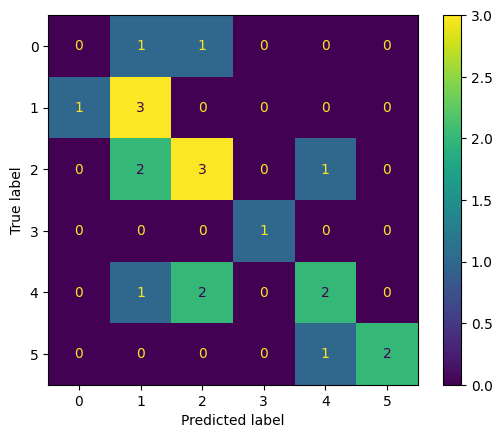

In [58]:
disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.show()

In [59]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_hat))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.43      0.75      0.55         4
           2       0.50      0.50      0.50         6
           3       1.00      1.00      1.00         1
           4       0.50      0.40      0.44         5
           5       1.00      0.67      0.80         3

    accuracy                           0.52        21
   macro avg       0.57      0.55      0.55        21
weighted avg       0.53      0.52      0.51        21



In [60]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

models = {
    "rfc": (RandomForestClassifier(), {"n_estimators": [100,200], "max_depth": [3,5,None]}),
    "gbc": (GradientBoostingClassifier(), {"n_estimators": [100,200], "learning_rate": [0.05,0.1]}),
    "svc": (SVC(), {"C": [0.1,1,10], "kernel": ["rbf","linear"]})
}

for name, (model, params) in models.items():
    gs = GridSearchCV(model, params, cv=5, scoring="accuracy")
    gs.fit(X_train, y_train)
    print(f"{name}: {gs.best_score_:.3f} -- {gs.best_params_}")

C:\Users\Berkay\Desktop\ML_projects\LSTM_sentiment\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


rfc: 0.481 -- {'max_depth': None, 'n_estimators': 100}


C:\Users\Berkay\Desktop\ML_projects\LSTM_sentiment\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


gbc: 0.596 -- {'learning_rate': 0.1, 'n_estimators': 200}


C:\Users\Berkay\Desktop\ML_projects\LSTM_sentiment\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


svc: 0.317 -- {'C': 1, 'kernel': 'rbf'}


In [61]:
params = {
    "n_estimators": [150, 200, 250],
    "learning_rate": [0.08, 0.1, 0.12],
    "max_depth": [2, 3, 4],
    "subsample": [0.8, 1.0]
}
gs = GridSearchCV(GradientBoostingClassifier(), params, cv=5, scoring="accuracy")
gs.fit(X_train, y_train)
print(gs.best_score_, gs.best_params_)

C:\Users\Berkay\Desktop\ML_projects\LSTM_sentiment\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


0.6175675675675676 {'learning_rate': 0.12, 'max_depth': 4, 'n_estimators': 200, 'subsample': 1.0}


In [67]:
best_model = GradientBoostingClassifier(learning_rate= 0.12, max_depth= 4, n_estimators= 200, subsample=1.0)
best_model.fit(X,y)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.12
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",200
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",4
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``,

In [68]:
na_predictions = best_model.predict(cabin_X_test[features])
cabin_X_test["Cabin_Deck"] = na_predictions
full_df = pd.concat([cabin_X_train, cabin_X_test], axis=0).sort_index()

In [70]:
full_df.isna().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
train          0
Title          0
Cabin_Deck     0
dtype: int64

In [72]:
features = ["Pclass","Sex","Age","Parch","Ticket","Fare","Cabin_Deck","Embarked","Title"]
target = "Survived"

X = full_df[features]
y = full_df[target]

In [73]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)

In [74]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

models = {
    "rfc": (RandomForestClassifier(), {"n_estimators": [100,200], "max_depth": [3,5,None]}),
    "gbc": (GradientBoostingClassifier(), {"n_estimators": [100,200], "learning_rate": [0.05,0.1]}),
    "svc": (SVC(), {"C": [0.1,1,10], "kernel": ["rbf","linear"]})
}

for name, (model, params) in models.items():
    gs = GridSearchCV(model, params, cv=5, scoring="accuracy")
    gs.fit(X_train, y_train)
    print(f"{name}: {gs.best_score_:.3f} -- {gs.best_params_}")

rfc: 0.815 -- {'max_depth': None, 'n_estimators': 100}
gbc: 0.816 -- {'learning_rate': 0.1, 'n_estimators': 200}
svc: 0.795 -- {'C': 10, 'kernel': 'linear'}


In [76]:
params = {
    "n_estimators": [150, 200, 250,300,500],
    "learning_rate": [0.05,0.08, 0.1, 0.12,0.15],
    "max_depth": [2, 3, 4, 5, 6],
    "subsample": [0.8, 1.0]
}
gs = GridSearchCV(GradientBoostingClassifier(), params, cv=5, scoring="accuracy")
gs.fit(X_train, y_train)
print(gs.best_score_, gs.best_params_)

0.8342952821826062 {'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 300, 'subsample': 0.8}


In [78]:
test_df.isna().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
train            0
dtype: int64

In [85]:
test_df["Age"] = age_imputer.transform(test_df[["Age"]])
test_df["Fare"] = test_df.groupby("Pclass")["Fare"].transform(lambda x: x.fillna(x.median()))
test_df['Title'] = test_df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)

In [95]:
test_df["Cabin_Deck"] = test_df["Cabin"].str[0]

for col in str_cols:
    known_labels = set(encoders[col].classes_)
    test_df[col] = test_df[col].astype(str).apply(
        lambda x: x if x in known_labels else "unknown"
    )
    if "unknown" not in encoders[col].classes_:
        encoders[col].classes_ = np.append(encoders[col].classes_, "unknown")
    test_df[col] = encoders[col].transform(test_df[col])


for col in num_cols:
    test_df[col] = scalers[col].transform(test_df[[col]])

test_df_cabin = test_df[test_df["Cabin"].notna()]
test_df_no_cabin = test_df[test_df["Cabin"].isna()]

AttributeError: Can only use .str accessor with string values, not integer

In [92]:
import numpy as np

test_cols = test_df_no_cabin.columns.to_list()
for col in test_cols:
    if col in str_cols:
        known_labels = set(encoders[col].classes_)
        test_df[col] = test_df[col].astype(str).apply(
            lambda x: x if x in known_labels else "unknown"
        )

        if "unknown" not in encoders[col].classes_:
            encoders[col].classes_ = np.append(encoders[col].classes_, "unknown")
        test_df[col] = encoders[col].transform(test_df[col])

In [93]:
features = ["Pclass","Sex","Age","SibSp","Parch","Ticket","Fare","Embarked","Title"]
test_na_predictions = best_model.predict(test_df_no_cabin[features])
test_df_no_cabin["Cabin_Deck"] = test_na_predictions
full_df = pd.concat([test_df_cabin, test_df_no_cabin], axis=0).sort_index()

ValueError: could not convert string to float: 'male'